# Basic Footprint Dimensions (L, a, b, c)

Several shape parameters (GNDT beta1/beta2/beta6, ASCE 7 / NTC-23 setback
ratios) are built from basic plan dimensions that must be defined for an
arbitrary, possibly non-rectangular, footprint:

- **L1, L2** — the two principal plan dimensions, from either the minimum
  bounding box (`direction.bbox`) or the principal axes of inertia
  (`direction.inertia`).
- **a** — the smallest side of the footprint's "main rectangular element",
  built from the largest inscribed circle and its tangent points
  (`geometry.main_element_a_lengths_batch`).
- **b, c** — the width and protrusion depth of the dominant setback, from
  the convex-hull-difference construction (`geometry.setback_gndt_metrics`).

This notebook exercises the low-level `geometry` helpers directly (the
`shape.py` norm parameters call these same functions internally), first on
idealized L/T/X shapes with a known-by-construction answer, then on the
three real pilot-area datasets.

## Setup

In [1]:
import sys
sys.path.insert(0, "../tests")  # so `import shapes` finds tests/shapes.py

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from footprint_attributes.geometry import (
    min_bounding_box,
    main_element_a_lengths_batch,
    setback_gndt_metrics,
    ensure_projected,
)
from shapes import (
    gdf_of, l_shape_polygon, t_shape_polygon, x_shape_polygon,
    asymmetric_l_shape_polygon,
)
import pandas as pd


## Part 1 — Idealized shapes

- **L-shape**: 20x20 square minus a 10x10 corner notch (1 setback).
- **T-shape**: 4m-wide stem + 20m-wide top bar (2 symmetric setbacks).
- **X-shape**: asymmetric cross (4 setbacks).
- **asymmetric L-shape**: 30x20 rectangle minus a 20x8 notch, `L1 != L2`,
  notch off-centre — known setback ratio 0.4.

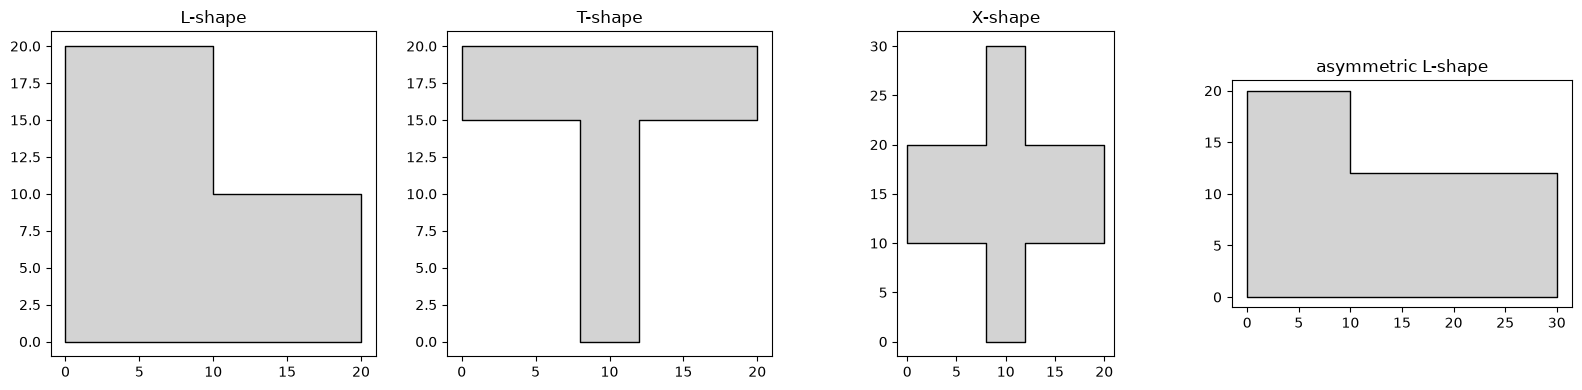

In [2]:
shapes = {
    "L-shape": gdf_of(l_shape_polygon()),
    "T-shape": gdf_of(t_shape_polygon()),
    "X-shape": gdf_of(x_shape_polygon()),
    "asymmetric L-shape": gdf_of(asymmetric_l_shape_polygon()),
}

fig, axes = plt.subplots(1, len(shapes), figsize=(4 * len(shapes), 4))
for ax, (name, g) in zip(axes, shapes.items()):
    g.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
    ax.set_title(name)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### L1, L2, a1, a2, setback ratio for each idealized shape

In [3]:
rows = []
for name, g in shapes.items():
    L1, dir1, L2, dir2 = min_bounding_box(g)
    a1, a2, centers = main_element_a_lengths_batch(g, dir1, dir2)
    ratio, b, c = setback_gndt_metrics(g, L1, dir1, L2, dir2)
    rows.append({
        "shape": name, "L1": L1[0], "L2": L2[0],
        "a1": a1[0], "a2": a2[0],
        "setback_ratio": ratio[0], "b": b[0], "c": c[0],
    })

theory_df = pd.DataFrame(rows).set_index("shape")
theory_df


,L1,L2,a1,a2,setback_ratio,b,c
shape,,,,,,,
L-shape,20.000000,20.000000,10.000000,10.000000,0.500000,10.00000,10.000000
T-shape,20.000000,20.000000,5.003585,4.001616,0.400000,8.00000,5.000000
X-shape,25.988097,21.883186,9.390354,10.343887,0.301446,7.83401,5.105942
asymmetric L-shape,30.000000,20.000000,11.981604,10.028764,0.400000,8.00000,10.000000


The asymmetric L-shape's `setback_ratio` matches the known value of
0.4 (`min(b1/L1, b2/L2)` for a 30x20 rectangle with a 20x8 notch).

## Part 2 — Real data: the three pilot areas

Same basic-length construction, run on the actual digitised footprints
from San José (Costa Rica), Guatemala City, and Santo Domingo (Dominican
Republic).

In [4]:
CITY_FILES = {
    "san_jose": "data/san_jose_pilot_region.gpkg",
    "guatemala": "data/guatemala_pilot_region.gpkg",
    "santo_domingo": "data/santo_domingo_pilot_region.gpkg",
}

def load_city(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].reset_index(drop=True)
    if (gdf.geometry.type == "MultiPolygon").any():
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    gdf = gdf[gdf.geometry.type == "Polygon"].reset_index(drop=True)
    gdf.geometry = gdf.geometry.make_valid()
    gdf = gdf[gdf.geometry.type == "Polygon"].reset_index(drop=True)
    return gdf


In [5]:
results = {}
for city, path in CITY_FILES.items():
    gdf = load_city(path)
    gdf = ensure_projected(gdf)

    L1_bbox, dir1_bbox, L2_bbox, dir2_bbox = min_bounding_box(gdf)
    gdf["L1_bbox"] = L1_bbox
    gdf["L2_bbox"] = L2_bbox

    a1, a2, centers = main_element_a_lengths_batch(gdf, dir1_bbox, dir2_bbox)
    gdf["a1"] = a1
    gdf["a2"] = a2

    ratio, b, c = setback_gndt_metrics(gdf, L1_bbox, dir1_bbox, L2_bbox, dir2_bbox)
    gdf["setback_ratio"] = ratio
    gdf["setback_b"] = b
    gdf["setback_c"] = c

    dominant_a = np.where(np.array(L1_bbox) * np.array(a1) >= np.array(L2_bbox) * np.array(a2), a1, a2)
    dominant_L = np.where(np.array(L1_bbox) * np.array(a1) >= np.array(L2_bbox) * np.array(a2), L1_bbox, L2_bbox)
    gdf["beta1"] = dominant_a / (dominant_L + 1e-12)
    gdf["beta2"] = gdf["setback_ratio"]
    gdf["beta6"] = gdf["setback_c"] / (gdf["setback_b"] + 1e-12)

    results[city] = gdf
    print(f"{city:15s} {len(gdf):5d} footprints")


san_jose          911 footprints


guatemala         435 footprints


santo_domingo    1463 footprints


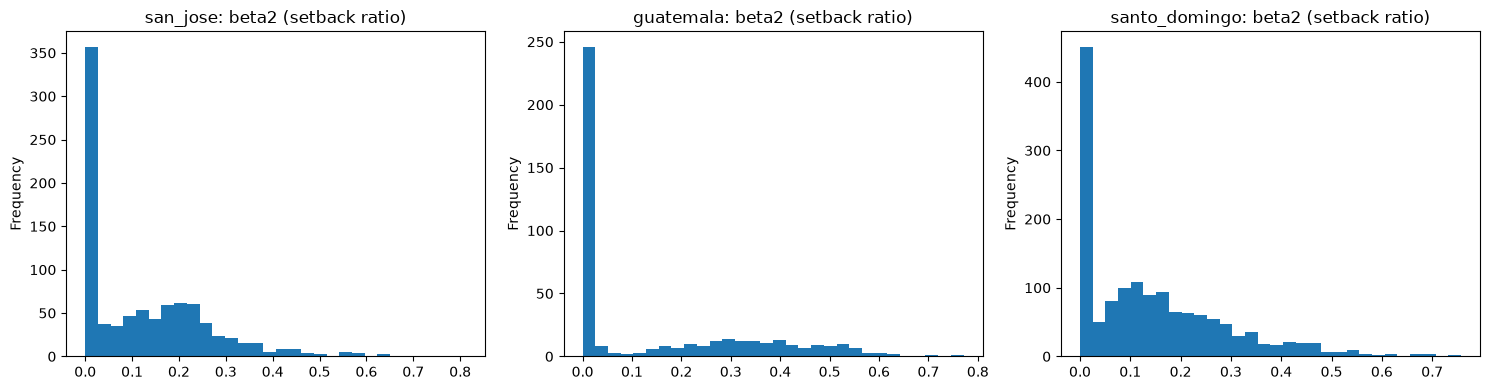

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (city, gdf) in zip(axes, results.items()):
    gdf["beta2"].plot.hist(ax=ax, bins=30)
    ax.set_title(f"{city}: beta2 (setback ratio)")
plt.tight_layout()
plt.show()


## Result

One GeoDataFrame per city, each carrying the basic-length building
blocks. Suggested columns to visualise on a map:

- `beta1`, `beta2`, `beta6` — GNDT masonry shape indices
- `setback_ratio` — ASCE7/NTC-23-style setback ratio


In [7]:
san_jose_gdf = results["san_jose"]
guatemala_gdf = results["guatemala"]
santo_domingo_gdf = results["santo_domingo"]

map_columns = [
    "id", "L1_bbox", "L2_bbox", "beta1", "beta2", "beta6",
    "setback_ratio", "geometry",
]
san_jose_gdf


,id,city,height,n_storeys,year,code_quality,structural_system,simplified_structural_system,roof,geometry,L1_bbox,L2_bbox,a1,a2,setback_ratio,setback_b,setback_c,beta1,beta2,beta6
0,1000009.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,metallic,"POLYGON ((817592.282 1098630.841, 817583.141 1...",13.870306,12.101991,7.249642,9.199678,0.000000,0.000000,0.000000,0.760179,0.000000,0.000000
1,1219.0,san_jose,6.0,2.0,1975,pre_code,M,M,metallic,"POLYGON ((817554.533 1098638.188, 817559.35 10...",22.624348,7.211505,7.056378,3.548569,0.000000,0.000000,0.000000,0.311893,0.000000,0.000000
2,1000010.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,dark_shadow,"POLYGON ((817593.338 1098634.876, 817591.389 1...",13.532780,4.678581,4.647321,4.647321,0.000000,0.000000,0.000000,0.343412,0.000000,0.000000
3,1221.0,san_jose,6.0,2.0,1985,low_code,M,M,bright_concrete,"POLYGON ((817509.464 1098646.298, 817509.417 1...",19.621873,5.940149,5.905389,3.276692,0.027276,0.162025,11.847866,0.300959,0.027276,73.123485
4,1222.0,san_jose,6.0,2.0,1988,medium_code,M,M,metallic,"POLYGON ((817484.519 1098643.546, 817484.505 1...",15.256333,9.327421,6.077779,4.158927,0.337829,3.151076,4.079593,0.398377,0.337829,1.294667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,1000029.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,metallic,"POLYGON ((817487.513 1099327.718, 817489.214 1...",21.767402,7.094139,6.927027,3.502068,0.000000,0.000000,0.000000,0.318229,0.000000,0.000000
907,1000030.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,dark_shadow,"POLYGON ((817491.914 1098875.344, 817490.37 10...",35.096331,17.241336,17.096527,8.597297,0.000000,0.000000,0.000000,0.487131,0.000000,0.000000
908,1000031.0,san_jose,NaN,NaN,1985,low_code,NaN,NaN,metallic,"POLYGON ((817594.418 1098785.886, 817594.699 1...",19.032748,11.888973,11.786047,5.998697,0.018521,0.220192,11.693809,0.619251,0.018521,53.107216
909,1000032.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,dark_shadow,"POLYGON ((817661.05 1098730.134, 817658.341 10...",22.352464,3.693766,3.647298,1.850181,0.000000,0.000000,0.000000,0.163172,0.000000,0.000000


In [8]:
guatemala_gdf


,id,city,height,n_storeys,year,code_quality,structural_system,simplified_structural_system,roof,geometry,L1_bbox,L2_bbox,a1,a2,setback_ratio,setback_b,setback_c,beta1,beta2,beta6
0,7,guatemala,21.0,7.0,1985,pre_code,CR,CR,metallic,"POLYGON ((767790.902 1620302.842, 767786.491 1...",36.791441,26.609313,18.865857,17.152200,0.296497,7.889583,17.085494,0.512778,0.296497,2.165576
1,8,guatemala,6.0,2.0,1985,pre_code,CR,CR,bright_concrete,"POLYGON ((767692.792 1620324.14, 767686.494 16...",40.661726,37.539257,27.957582,32.396985,0.202925,8.251264,28.154427,0.863016,0.202925,3.412135
2,9,guatemala,18.0,6.0,1985,pre_code,CR,CR,bright_concrete,"POLYGON ((767653.981 1620317.212, 767650.617 1...",33.753861,22.784936,7.763627,14.760592,0.000000,0.000000,0.000000,0.647822,0.000000,0.000000
3,10,guatemala,9.0,3.0,1985,pre_code,CR,CR,dark_shadow,"POLYGON ((767631.691 1620320.309, 767627.553 1...",33.946299,20.539929,20.240874,10.223160,0.013298,0.273144,20.033806,0.596262,0.013298,73.345185
4,53,guatemala,3.0,1.0,1985,pre_code,M,M,bright_concrete,"POLYGON ((767736.621 1620273.206, 767737.434 1...",17.281690,7.399867,7.338370,3.712769,0.000000,0.000000,0.000000,0.424633,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,1000020,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((767967.054 1620766.917, 767967.159 1...",13.606980,7.991534,5.177102,5.028453,0.533882,4.266533,6.130942,0.380474,0.533882,1.436984
431,1000021,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((767957.402 1620784.045, 767971.325 1...",14.514457,11.088897,10.978309,5.532001,0.005442,0.060345,1.053121,0.756371,0.005442,17.451708
432,1000024,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((767742.538 1620785.376, 767743.107 1...",18.212842,9.681661,9.585799,0.668882,0.000000,0.000000,0.000000,0.526321,0.000000,0.000000
433,1000001,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((767743.478 1620338.287, 767750.941 1...",27.559919,14.053234,13.902149,7.022546,0.006837,0.096085,6.219629,0.504434,0.006837,64.730736


In [9]:
santo_domingo_gdf


,id,city,height,n_storeys,year,code_quality,structural_system,simplified_structural_system,roof,geometry,L1_bbox,L2_bbox,a1,a2,setback_ratio,setback_b,setback_c,beta1,beta2,beta6
0,756,santo_domingo,6.0,2.0,1985,low_code,M,M,metallic,"POLYGON ((400755.503 2041946.512, 400763.567 2...",17.736671,10.427929,7.285950,6.757297,0.296443,3.091291,6.691631,0.410785,0.296443,2.164672
1,1448,santo_domingo,3.0,1.0,1985,low_code,M,M,metallic,"POLYGON ((400752.768 2041786.239, 400747.871 2...",16.845533,9.912854,9.871938,4.124672,0.083000,1.398179,7.658799,0.586027,0.083000,5.477695
2,783,santo_domingo,3.0,1.0,1985,low_code,M,M,metallic,"POLYGON ((400728.96 2042022.949, 400740.02 204...",12.803540,8.754279,8.590832,4.419327,0.031169,0.399078,3.265923,0.670973,0.031169,8.183667
3,506,santo_domingo,9.0,3.0,1985,low_code,M,M,metallic,"POLYGON ((400621.845 2042180.408, 400624.684 2...",11.048662,6.829210,6.736911,3.191041,0.114906,1.269552,4.746304,0.609749,0.114906,3.738565
4,952,santo_domingo,27.0,9.0,1985,low_code,CR,CR,asphalt,"POLYGON ((399942.413 2041384.087, 399943.943 2...",29.461327,15.602622,7.164203,13.919043,0.516223,15.208619,6.102126,0.892096,0.516223,0.401228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458,411,santo_domingo,NaN,NaN,1985,low_code,NaN,NaN,NaN,"POLYGON ((400660.873 2042109.183, 400673.948 2...",35.048138,24.330678,12.887848,4.404539,0.474184,11.537227,8.555425,0.367718,0.474184,0.741549
1459,410,santo_domingo,9.0,3.0,1985,low_code,M,M,NaN,"POLYGON ((400662.197 2042101.872, 400655.932 2...",12.117208,10.260292,8.362049,7.532480,0.112397,1.153225,7.638711,0.690097,0.112397,6.623781
1460,409,santo_domingo,12.0,4.0,1989,low_code,M,M,NaN,"POLYGON ((400685.397 2042099.449, 400695.452 2...",44.439927,34.224406,7.872010,15.322822,0.340596,15.136057,13.097605,0.447716,0.340596,0.865325
1461,408,santo_domingo,15.0,5.0,1985,low_code,M,M,NaN,"POLYGON ((400698.257 2042029.509, 400694.637 2...",24.112753,12.465234,12.435526,5.067318,0.118023,1.471180,18.837354,0.515724,0.118023,12.804246


In [10]:
map_columns


['id',
 'L1_bbox',
 'L2_bbox',
 'beta1',
 'beta2',
 'beta6',
 'setback_ratio',
 'geometry']